# BEAM Stage 1: CG Model Evaluation

**Complete evaluation framework for CG models on real protein data**

## System Information
- **Protein**: Pertactin (106 residues)
- **CG Model**: Upside (backbone atoms: N, CA, C)
- **AA Reference**: CHARMM all-atom simulation
- **Trajectory Length**: 2000 frames each

## Evaluation Dimensions
1. **Distribution-based**: RDF + CV distributions (KS, KL, JS, overlap)
2. **Dynamics-based**: Autocorrelation times, speedup factors
3. **Sampling efficiency**: ESS, basin discovery, variance

---

## 0. Configuration

**Customize your alignment and selection here**

In [1]:
# ============================
# USER CONFIGURATION
# ============================
import sys
sys.path.insert(0, '..')
# File paths
DATA_DIR = "../data"
OUTPUT_DIR = "../results/stage1_evaluation"

# CG files
CG_DCD = f"{DATA_DIR}/cg_upside.dcd"
CG_TOPOLOGY = f"{DATA_DIR}/C_upside.psf"

# AA files
AA_DCD = f"{DATA_DIR}/aa.dcd"
AA_TOPOLOGY = f"{DATA_DIR}/Cside_protein.pdb"

# Reference structure for alignment
REFERENCE_PDB = f"{DATA_DIR}/Cside_protein.pdb"

# ============================
# ALIGNMENT CONFIGURATION
# ============================
# Customize your alignment selection here
# Examples:
#   "name CA"                    - All CA atoms
#   "name CA and resid 10-100"   - CA atoms from residue 10 to 100
#   "backbone and resid 1-106"   - All backbone atoms from residue 1 to 106
#   "protein and not resid 1-5"  - Exclude first 5 residues

ALIGN_SELECTION = "name CA and resid 446 to 468"  # 👈 CUSTOMIZE THIS

# ============================
# FEATURE EXTRACTION
# ============================
CG_MODEL = "upside"  # CG force field being evaluated

# ============================
# RDF PARAMETERS
# ============================
RDF_PARAMS = {
    'r_max': 15,      # Maximum distance (angstrom)
    'bins': 100,       # Number of bins
    'box_size': None   # Set to box size if using PBC, None otherwise
}

# ============================
# SAMPLING PARAMETERS
# ============================
N_CLUSTERS = 10  # Number of clusters for basin discovery

print("="*70)
print("CONFIGURATION")
print("="*70)
print(f"Alignment selection: {ALIGN_SELECTION}")
print(f"CG model: {CG_MODEL}")
print(f"Output directory: {OUTPUT_DIR}")
print("="*70)

CONFIGURATION
Alignment selection: name CA and resid 446 to 468
CG model: upside
Output directory: ../results/stage1_evaluation


## 1. Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import MDAnalysis as mda
from MDAnalysis.analysis import align
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# BEAM imports
from beam import CGEvaluator
from beam.cg_models import get_cg_model_config

# Plotting setup
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Create output directory
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print("✓ Imports successful")
print(f"✓ Output directory created: {OUTPUT_DIR}")

✓ Imports successful
✓ Output directory created: ../results/stage1_evaluation


## 2. Load Trajectories

In [3]:
print("\n" + "="*70)
print("LOADING TRAJECTORIES")
print("="*70)

# Load CG trajectory
print("\n[1/3] Loading CG trajectory...")
u_cg = mda.Universe(CG_TOPOLOGY, CG_DCD)
print(f"  ✓ CG loaded")
print(f"    Atoms: {u_cg.atoms.n_atoms}")
print(f"    Residues: {u_cg.atoms.n_residues}")
print(f"    Frames: {len(u_cg.trajectory)}")

# Load AA trajectory
print("\n[2/3] Loading AA trajectory...")
u_aa = mda.Universe(AA_TOPOLOGY, AA_DCD)
print(f"  ✓ AA loaded")
print(f"    Atoms: {u_aa.atoms.n_atoms}")
print(f"    Residues: {u_aa.atoms.n_residues}")
print(f"    Frames: {len(u_aa.trajectory)}")

# Load reference structure
print("\n[3/3] Loading reference structure...")
u_ref = mda.Universe(REFERENCE_PDB)
print(f"  ✓ Reference loaded")
print(f"    Atoms: {u_ref.atoms.n_atoms}")

print("\n✓ All trajectories loaded successfully")


LOADING TRAJECTORIES

[1/3] Loading CG trajectory...
  ✓ CG loaded
    Atoms: 318
    Residues: 106
    Frames: 2000

[2/3] Loading AA trajectory...
  ✓ AA loaded
    Atoms: 1578
    Residues: 106
    Frames: 2000

[3/3] Loading reference structure...
  ✓ Reference loaded
    Atoms: 1578

✓ All trajectories loaded successfully


## 3. Align Trajectories

Remove overall translation and rotation by aligning to reference structure.


ALIGNING TRAJECTORIES

Alignment selection: 'name CA and resid 446 to 468'

[1/4] Verifying alignment selection...
  ✓ CG alignment atoms: 23
  ✓ AA alignment atoms: 23
  ✓ Reference alignment atoms: 23

[2/4] Aligning CG trajectory to reference...
  ✓ CG alignment complete
    Initial RMSD: 0.000 Å
    Mean RMSD: 4.713 Å
    Max RMSD: 13.837 Å

[3/4] Aligning AA trajectory to reference...
  ✓ AA alignment complete
    Initial RMSD: 0.246 Å
    Mean RMSD: 0.819 Å
    Max RMSD: 1.498 Å

[4/4] Plotting alignment RMSD...


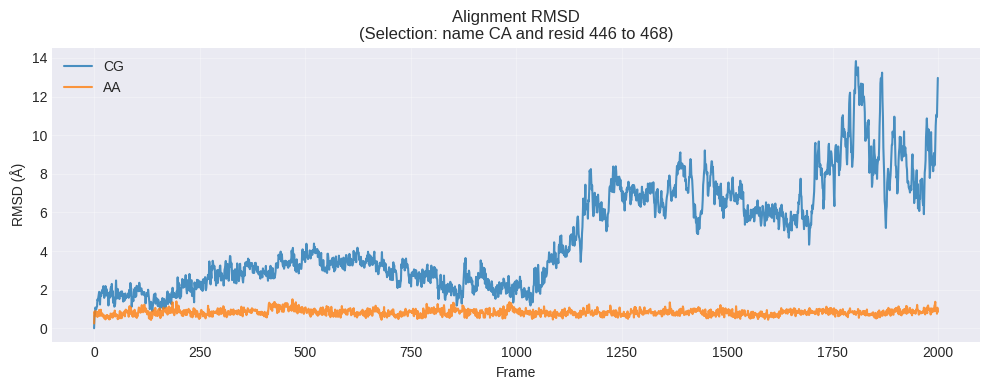


✓ Alignment complete


In [4]:
print("\n" + "="*70)
print("ALIGNING TRAJECTORIES")
print("="*70)
print(f"\nAlignment selection: '{ALIGN_SELECTION}'")

# Verify selection works
print("\n[1/4] Verifying alignment selection...")
try:
    cg_align_atoms = u_cg.select_atoms(ALIGN_SELECTION)
    aa_align_atoms = u_aa.select_atoms(ALIGN_SELECTION)
    ref_align_atoms = u_ref.select_atoms(ALIGN_SELECTION)
    
    print(f"  ✓ CG alignment atoms: {cg_align_atoms.n_atoms}")
    print(f"  ✓ AA alignment atoms: {aa_align_atoms.n_atoms}")
    print(f"  ✓ Reference alignment atoms: {ref_align_atoms.n_atoms}")
    
    if cg_align_atoms.n_atoms != aa_align_atoms.n_atoms:
        raise ValueError(
            f"CG and AA have different number of alignment atoms! "
            f"CG: {cg_align_atoms.n_atoms}, AA: {aa_align_atoms.n_atoms}"
        )
    
    if cg_align_atoms.n_atoms == 0:
        raise ValueError(f"No atoms selected with '{ALIGN_SELECTION}'")
        
except Exception as e:
    print(f"\n❌ ERROR: {e}")
    print("\nPlease check your ALIGN_SELECTION and try again.")
    raise

# Align CG trajectory
print("\n[2/4] Aligning CG trajectory to reference...")
aligner_cg = align.AlignTraj(
    u_cg,
    u_ref,
    select=ALIGN_SELECTION,
    in_memory=True,
    verbose=False
)
aligner_cg.run()

rmsd_cg = aligner_cg.results.rmsd  # RMSD values
print(f"  ✓ CG alignment complete")
print(f"    Initial RMSD: {rmsd_cg[0]:.3f} Å")
print(f"    Mean RMSD: {rmsd_cg.mean():.3f} Å")
print(f"    Max RMSD: {rmsd_cg.max():.3f} Å")

# Align AA trajectory
print("\n[3/4] Aligning AA trajectory to reference...")
aligner_aa = align.AlignTraj(
    u_aa,
    u_ref,
    select=ALIGN_SELECTION,
    in_memory=True,
    verbose=False
)
aligner_aa.run()

rmsd_aa = aligner_aa.results.rmsd
print(f"  ✓ AA alignment complete")
print(f"    Initial RMSD: {rmsd_aa[0]:.3f} Å")
print(f"    Mean RMSD: {rmsd_aa.mean():.3f} Å")
print(f"    Max RMSD: {rmsd_aa.max():.3f} Å")

# Plot RMSD
print("\n[4/4] Plotting alignment RMSD...")
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(rmsd_cg, label='CG', alpha=0.8)
ax.plot(rmsd_aa, label='AA', alpha=0.8)
ax.set_xlabel('Frame')
ax.set_ylabel('RMSD (Å)')
ax.set_title(f'Alignment RMSD\n(Selection: {ALIGN_SELECTION})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'alignment_rmsd.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Alignment complete")

## 4. Extract Features for Evaluation

Extract xyz coordinates as features. For Upside, this includes backbone atoms (N, CA, C).

In [5]:
print("\n" + "="*70)
print("FEATURE EXTRACTION")
print("="*70)

# Get CG model configuration
cg_config = get_cg_model_config(CG_MODEL)
print(f"\nCG Model: {CG_MODEL}")
print(f"  Description: {cg_config['description']}")
print(f"  Feature selection: {cg_config['feature_selection']}")
print(f"  Expected atoms/residue: {cg_config['expected_atoms_per_residue']}")

# Extract CG features
print("\n[1/2] Extracting CG features...")
cg_feature_atoms = u_cg.select_atoms(cg_config['feature_selection'])
print(f"  Selected {cg_feature_atoms.n_atoms} atoms")
print(f"  Expected: {u_cg.atoms.n_residues * cg_config['expected_atoms_per_residue']} atoms")

cg_features = []
for ts in u_cg.trajectory:
    cg_features.append(cg_feature_atoms.positions.flatten())
cg_features = np.array(cg_features)

print(f"  ✓ CG features extracted")
print(f"    Shape: {cg_features.shape}")
print(f"    ({cg_features.shape[0]} frames × {cg_features.shape[1]} features)")

# Extract AA features (same atoms as CG for comparison)
print("\n[2/2] Extracting AA features...")
aa_feature_atoms = u_aa.select_atoms(cg_config['feature_selection'])
print(f"  Selected {aa_feature_atoms.n_atoms} atoms")

aa_features = []
for ts in u_aa.trajectory:
    aa_features.append(aa_feature_atoms.positions.flatten())
aa_features = np.array(aa_features)

print(f"  ✓ AA features extracted")
print(f"    Shape: {aa_features.shape}")

# Verify compatibility
if cg_features.shape[1] != aa_features.shape[1]:
    raise ValueError(
        f"CG and AA feature dimensions don't match! "
        f"CG: {cg_features.shape[1]}, AA: {aa_features.shape[1]}"
    )

print(f"\n✓ Feature extraction complete")
print(f"  Both trajectories have {cg_features.shape[1]} features")


FEATURE EXTRACTION

CG Model: upside
  Description: Upside force field (heavy atom-only)
  Feature selection: name N CA C
  Expected atoms/residue: 3

[1/2] Extracting CG features...
  Selected 318 atoms
  Expected: 318 atoms
  ✓ CG features extracted
    Shape: (2000, 954)
    (2000 frames × 954 features)

[2/2] Extracting AA features...
  Selected 318 atoms
  ✓ AA features extracted
    Shape: (2000, 954)

✓ Feature extraction complete
  Both trajectories have 954 features


## 5. Extract Positions for RDF

For RDF calculation, we use backbone atoms only (mapped to same resolution for CG and AA).

In [6]:
print("\n" + "="*70)
print("POSITION EXTRACTION FOR RDF")
print("="*70)

# Extract CG CA positions
print("\n[1/2] Extracting CG CA positions...")
cg_ca_atoms = u_cg.select_atoms("name CA")
print(f"  Selected {cg_ca_atoms.n_atoms} CA atoms")

cg_positions = []
for ts in u_cg.trajectory:
    cg_positions.append(cg_ca_atoms.positions.copy())
cg_positions = np.array(cg_positions)

print(f"  ✓ CG positions extracted")
print(f"    Shape: {cg_positions.shape}")

# Extract AA CA positions (mapped to CG resolution)
print("\n[2/2] Extracting AA backbone positions...")
aa_ca_atoms = u_aa.select_atoms("name CA ")
print(f"  Selected {aa_ca_atoms.n_atoms} CA atoms")

aa_positions = []
for ts in u_aa.trajectory:
    aa_positions.append(aa_ca_atoms.positions.copy())
aa_positions = np.array(aa_positions)

print(f"  ✓ AA positions extracted")
print(f"    Shape: {aa_positions.shape}")

# Verify same number of CA atoms
if cg_positions.shape[1] != aa_positions.shape[1]:
    raise ValueError(
        f"CG and AA have different number of CA atoms! "
        f"CG: {cg_positions.shape[1]}, AA: {aa_positions.shape[1]}"
    )

print(f"\n✓ Position extraction complete")
print(f"  Both have {cg_positions.shape[1]} CA atoms for RDF comparison")


POSITION EXTRACTION FOR RDF

[1/2] Extracting CG CA positions...
  Selected 106 CA atoms
  ✓ CG positions extracted
    Shape: (2000, 106, 3)

[2/2] Extracting AA backbone positions...
  Selected 106 CA atoms
  ✓ AA positions extracted
    Shape: (2000, 106, 3)

✓ Position extraction complete
  Both have 106 CA atoms for RDF comparison


## 6. Define Collective Variables

Define physics-informed CVs to evaluate CG model quality.

In [7]:
print("\n" + "="*70)
print("COLLECTIVE VARIABLE DEFINITIONS")
print("="*70)

def radius_of_gyration(features):
    """
    Radius of gyration from xyz features.
    
    Rg = sqrt(mean((r_i - r_com)^2))
    
    Parameters
    ----------
    features : np.ndarray
        Flattened xyz coordinates, shape (n_frames, n_features)
        where n_features = n_atoms * 3
        
    Returns
    -------
    rg : np.ndarray
        Radius of gyration for each frame, shape (n_frames,)
    """
    n_frames, n_features = features.shape
    n_atoms = n_features // 3
    
    # Reshape to (n_frames, n_atoms, 3)
    positions = features.reshape(n_frames, n_atoms, 3)
    
    # Center of mass
    com = positions.mean(axis=1, keepdims=True)
    
    # Rg calculation
    rg = np.sqrt(np.mean(np.sum((positions - com)**2, axis=2), axis=1))
    
    return rg


def end_to_end_distance(features):
    """
    End-to-end distance (first to last CA).
    
    For Upside (N, CA, C pattern): CA is at indices 1, 4, 7, ...
    
    Parameters
    ----------
    features : np.ndarray
        Flattened xyz coordinates
    Returns
    -------
    e2e : np.ndarray
        End-to-end distance for each frame
    """
    n_frames, n_features = features.shape
    n_atoms = n_features // 3
    
    positions = features.reshape(n_frames, n_atoms, 3)
    
    # For Upside: N, CA, C repeating pattern
    # CA is at indices: 1, 4, 7, 10, ...
    ca_indices = np.arange(1, n_atoms, 3)
    
    if len(ca_indices) < 2:
        raise ValueError("Not enough CA atoms for end-to-end distance")
    
    first_ca = positions[:, ca_indices[0], :]   # First CA
    last_ca = positions[:, ca_indices[-1], :]   # Last CA
    
    e2e = np.linalg.norm(last_ca - first_ca, axis=1)
    
    return e2e


def contact_number(features, cutoff=8.0):
    """
    Number of CA-CA contacts within cutoff distance.
    
    Contact definition: CA-CA distance < cutoff (anstrom)
    Excludes nearest neighbors (i, i+1)
    
    Parameters
    ----------
    features : np.ndarray
        Flattened xyz coordinates
    cutoff : float
        Contact distance cutoff in nm (default: 0.8 nm = 8 Å)
        
    Returns
    -------
    contacts : np.ndarray
        Number of contacts for each frame
    """
    n_frames, n_features = features.shape
    n_atoms = n_features // 3
    
    positions = features.reshape(n_frames, n_atoms, 3)
    
    # Extract CA positions (every 3rd atom starting at index 1)
    ca_indices = np.arange(1, n_atoms, 3)
    ca_positions = positions[:, ca_indices, :]
    
    n_ca = len(ca_indices)
    contacts = np.zeros(n_frames)
    
    for frame_idx in range(n_frames):
        ca_frame = ca_positions[frame_idx]
        
        # Count contacts (exclude neighbors)
        for i in range(n_ca):
            for j in range(i + 2, n_ca):  # Skip i and i+1
                dist = np.linalg.norm(ca_frame[i] - ca_frame[j])
                if dist < cutoff:
                    contacts[frame_idx] += 1
    
    return contacts


# Define CV list
cv_list = [
    ('Rg', radius_of_gyration),
    ('end_to_end', end_to_end_distance),
    ('contacts', contact_number)
]

print(f"\nDefined {len(cv_list)} collective variables:")
for cv_name, cv_func in cv_list:
    print(f"  - {cv_name}")

# Test CVs on CG data
print("\n" + "-"*70)
print("Testing CVs on CG trajectory:")
print("-"*70)
for cv_name, cv_func in cv_list:
    try:
        cv_values = cv_func(cg_features)
        print(f"  {cv_name:15s}: mean={cv_values.mean():7.3f}, std={cv_values.std():7.3f}, "
              f"min={cv_values.min():7.3f}, max={cv_values.max():7.3f}")
    except Exception as e:
        print(f"  {cv_name:15s}: ERROR - {e}")

print("\n✓ CV definitions complete")


COLLECTIVE VARIABLE DEFINITIONS

Defined 3 collective variables:
  - Rg
  - end_to_end
  - contacts

----------------------------------------------------------------------
Testing CVs on CG trajectory:
----------------------------------------------------------------------
  Rg             : mean= 18.059, std=  4.832, min= 12.497, max= 33.236
  end_to_end     : mean= 51.670, std= 16.419, min= 20.959, max=116.742
  contacts       : mean=313.748, std= 77.504, min=128.000, max=468.000

✓ CV definitions complete


## 7. Initialize CGEvaluator

In [8]:
print("\n" + "="*70)
print("INITIALIZING CG EVALUATOR")
print("="*70)

evaluator = CGEvaluator(
    cg_traj=cg_features,
    aa_traj=aa_features,
    cg_positions=cg_positions,
    aa_positions=aa_positions
)

print("\n✓ Evaluator initialized successfully")


INITIALIZING CG EVALUATOR
CGEvaluator initialized:
  CG features: (2000, 954)
  AA features: (2000, 954)
  CG positions: (2000, 106, 3)
  AA positions (mapped): (2000, 106, 3)

✓ Evaluator initialized successfully


## 8. Run Complete Evaluation

This will compute all metrics across three dimensions:
1. Distribution-based (RDF + CV distributions)
2. Dynamics-based (autocorrelation times)
3. Sampling efficiency (ESS, basin discovery, variance)

In [9]:
print("\n" + "="*70)
print("RUNNING COMPLETE EVALUATION")
print("="*70)

report = evaluator.evaluate_all(
    cv_list=cv_list,
    rdf_params=RDF_PARAMS,
    n_clusters=N_CLUSTERS,
    output_dir=OUTPUT_DIR,
    save_results=True
)

print("\n✓ Evaluation complete!")


RUNNING COMPLETE EVALUATION

BEAM CG MODEL EVALUATION - STAGE 1

Evaluating 3 collective variables
Mode: COMPARISON (CG vs AA)

DISTRIBUTION-BASED EVALUATION

[1] RDF comparison
  Computing RDF for CG...
  Computing RDF for AA...
    L2 error: 676.3335
    JS divergence: 0.0666

[2] CV distributions (3 CVs)

  Evaluating: Rg
    KS statistic: 0.8215
    JS divergence: 0.6912
    Overlap: 0.3756

  Evaluating: end_to_end
    KS statistic: 0.5505
    JS divergence: 0.4683
    Overlap: 0.5831

  Evaluating: contacts
    KS statistic: 0.8630
    JS divergence: 0.7332
    Overlap: 0.3425

DYNAMICS-BASED EVALUATION

  Evaluating: Rg
    tau_cg: 461.46
    tau_aa: 37.79
    Speedup: 0.08x

  Evaluating: end_to_end
    tau_cg: 156.63
    tau_aa: 31.40
    Speedup: 0.20x

  Evaluating: contacts
    tau_cg: 629.89
    tau_aa: 41.69
    Speedup: 0.07x

SAMPLING EFFICIENCY EVALUATION

  Evaluating: Rg
    ESS_cg: 2.2 (0.1%)
    Basins explored: 10/10
    CV variance: 23.3457

  Evaluating: end_to

## 9. Generate Summary

In [10]:
summary = evaluator.generate_summary(report)
print("\n" + summary)

# Save summary to file
summary_file = OUTPUT_DIR / "evaluation_summary.txt"
with open(summary_file, 'w') as f:
    f.write(summary)

print(f"\n✓ Summary saved to: {summary_file}")


BEAM CG EVALUATION SUMMARY

[DISTRIBUTION]
  RDF:
    L2 error: 676.3335
    JS divergence: 0.0666
  Rg:
    KS stat: 0.8215 (p=0.0000)
    JS div: 0.6912
    Overlap: 0.3756
  end_to_end:
    KS stat: 0.5505 (p=0.0000)
    JS div: 0.4683
    Overlap: 0.5831
  contacts:
    KS stat: 0.8630 (p=0.0000)
    JS div: 0.7332
    Overlap: 0.3425

[DYNAMICS]
  Rg:
    tau_cg: 461.46
    tau_aa: 37.79
    Speedup: 0.08x
  end_to_end:
    tau_cg: 156.63
    tau_aa: 31.40
    Speedup: 0.20x
  contacts:
    tau_cg: 629.89
    tau_aa: 41.69
    Speedup: 0.07x

[SAMPLING]
  Rg:
    ESS: 2.2 (0.1%)
    Basins: 10/10
    Variance: 23.3457
  end_to_end:
    ESS: 6.4 (0.3%)
    Basins: 10/10
    Variance: 269.5982
  contacts:
    ESS: 1.6 (0.1%)
    Basins: 10/10
    Variance: 6006.8922


✓ Summary saved to: ../results/stage1_evaluation/evaluation_summary.txt


## 10. Visualization

### 10.1 RDF Comparison

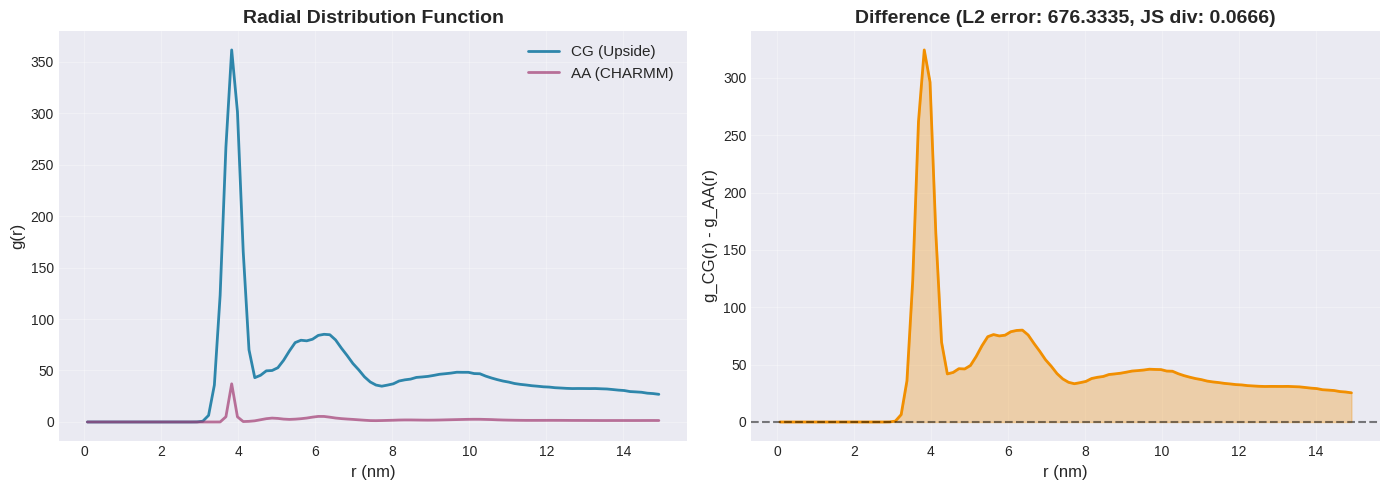

✓ RDF plot saved


In [11]:
if 'rdf' in report['distribution']:
    rdf = report['distribution']['rdf']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # g(r) overlay
    ax1.plot(rdf['r_bins'], rdf['g_cg'], label='CG (Upside)', 
             linewidth=2, color='#2E86AB')
    ax1.plot(rdf['r_bins'], rdf['g_aa'], label='AA (CHARMM)', 
             linewidth=2, color='#A23B72', alpha=0.7)
    ax1.set_xlabel('r (nm)', fontsize=12)
    ax1.set_ylabel('g(r)', fontsize=12)
    ax1.set_title('Radial Distribution Function', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # Difference plot
    diff = rdf['g_cg'] - rdf['g_aa']
    ax2.plot(rdf['r_bins'], diff, color='#F18F01', linewidth=2)
    ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax2.fill_between(rdf['r_bins'], 0, diff, alpha=0.3, color='#F18F01')
    ax2.set_xlabel('r (nm)', fontsize=12)
    ax2.set_ylabel('g_CG(r) - g_AA(r)', fontsize=12)
    ax2.set_title(f'Difference (L2 error: {rdf["l2_error"]:.4f}, JS div: {rdf["js_divergence"]:.4f})', 
                  fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'rdf_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ RDF plot saved")
else:
    print("⚠ RDF comparison skipped (positions not provided)")

### 10.2 CV Distribution Comparisons

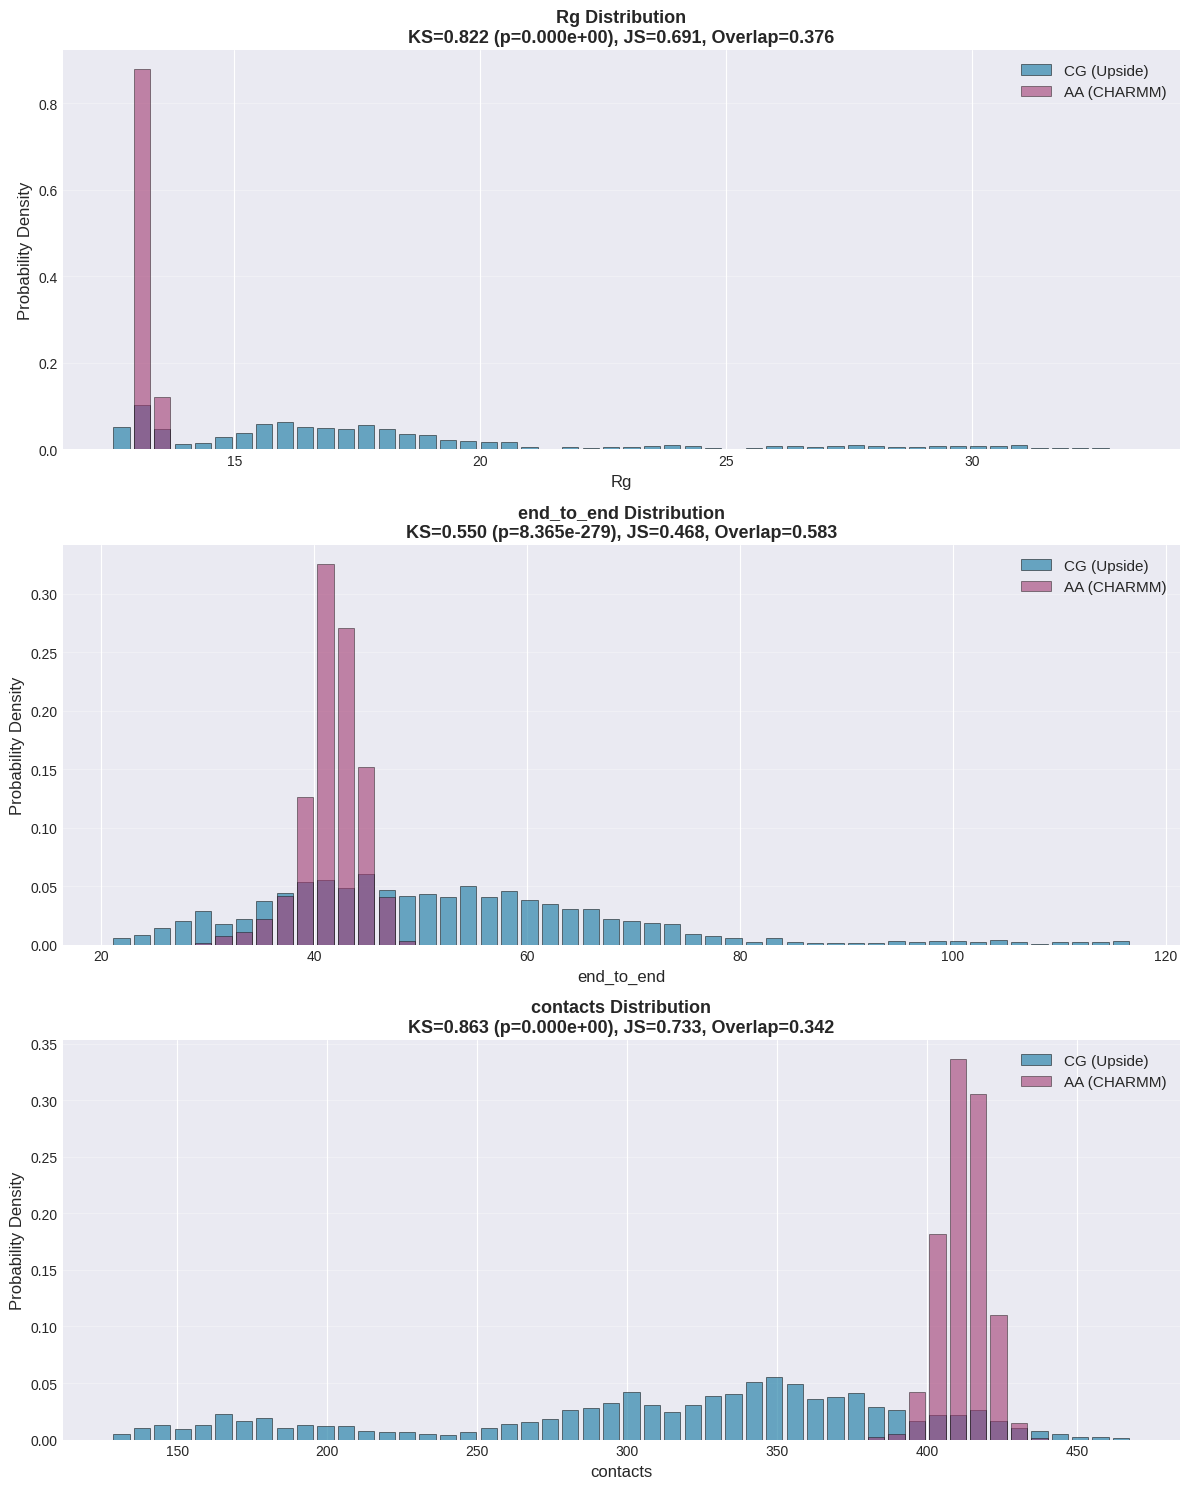

✓ CV distribution plots saved


In [12]:
n_cvs = len(cv_list)
fig, axes = plt.subplots(n_cvs, 1, figsize=(12, 5*n_cvs))
if n_cvs == 1:
    axes = [axes]

for idx, (cv_name, _) in enumerate(cv_list):
    dist = report['distribution'][cv_name]
    ax = axes[idx]
    
    # Bin centers and width
    bin_centers = 0.5 * (dist['bin_edges'][1:] + dist['bin_edges'][:-1])
    width = bin_centers[1] - bin_centers[0]
    
    # Plot histograms
    ax.bar(bin_centers, dist['cg_hist'], width=width*0.8, 
           label='CG (Upside)', alpha=0.7, color='#2E86AB', edgecolor='black', linewidth=0.5)
    
    if 'aa_hist' in dist:
        ax.bar(bin_centers, dist['aa_hist'], width=width*0.8,
               label='AA (CHARMM)', alpha=0.6, color='#A23B72', edgecolor='black', linewidth=0.5)
        
        # Metrics in title
        title = f"{cv_name} Distribution\n"
        title += f"KS={dist['ks_statistic']:.3f} (p={dist['ks_pvalue']:.3e}), "
        title += f"JS={dist['js_divergence']:.3f}, "
        title += f"Overlap={dist['overlap_coefficient']:.3f}"
        ax.set_title(title, fontsize=13, fontweight='bold')
    else:
        ax.set_title(f"{cv_name} Distribution (CG only)", 
                    fontsize=13, fontweight='bold')
    
    ax.set_xlabel(f'{cv_name}', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ CV distribution plots saved")

### 10.3 Autocorrelation Functions

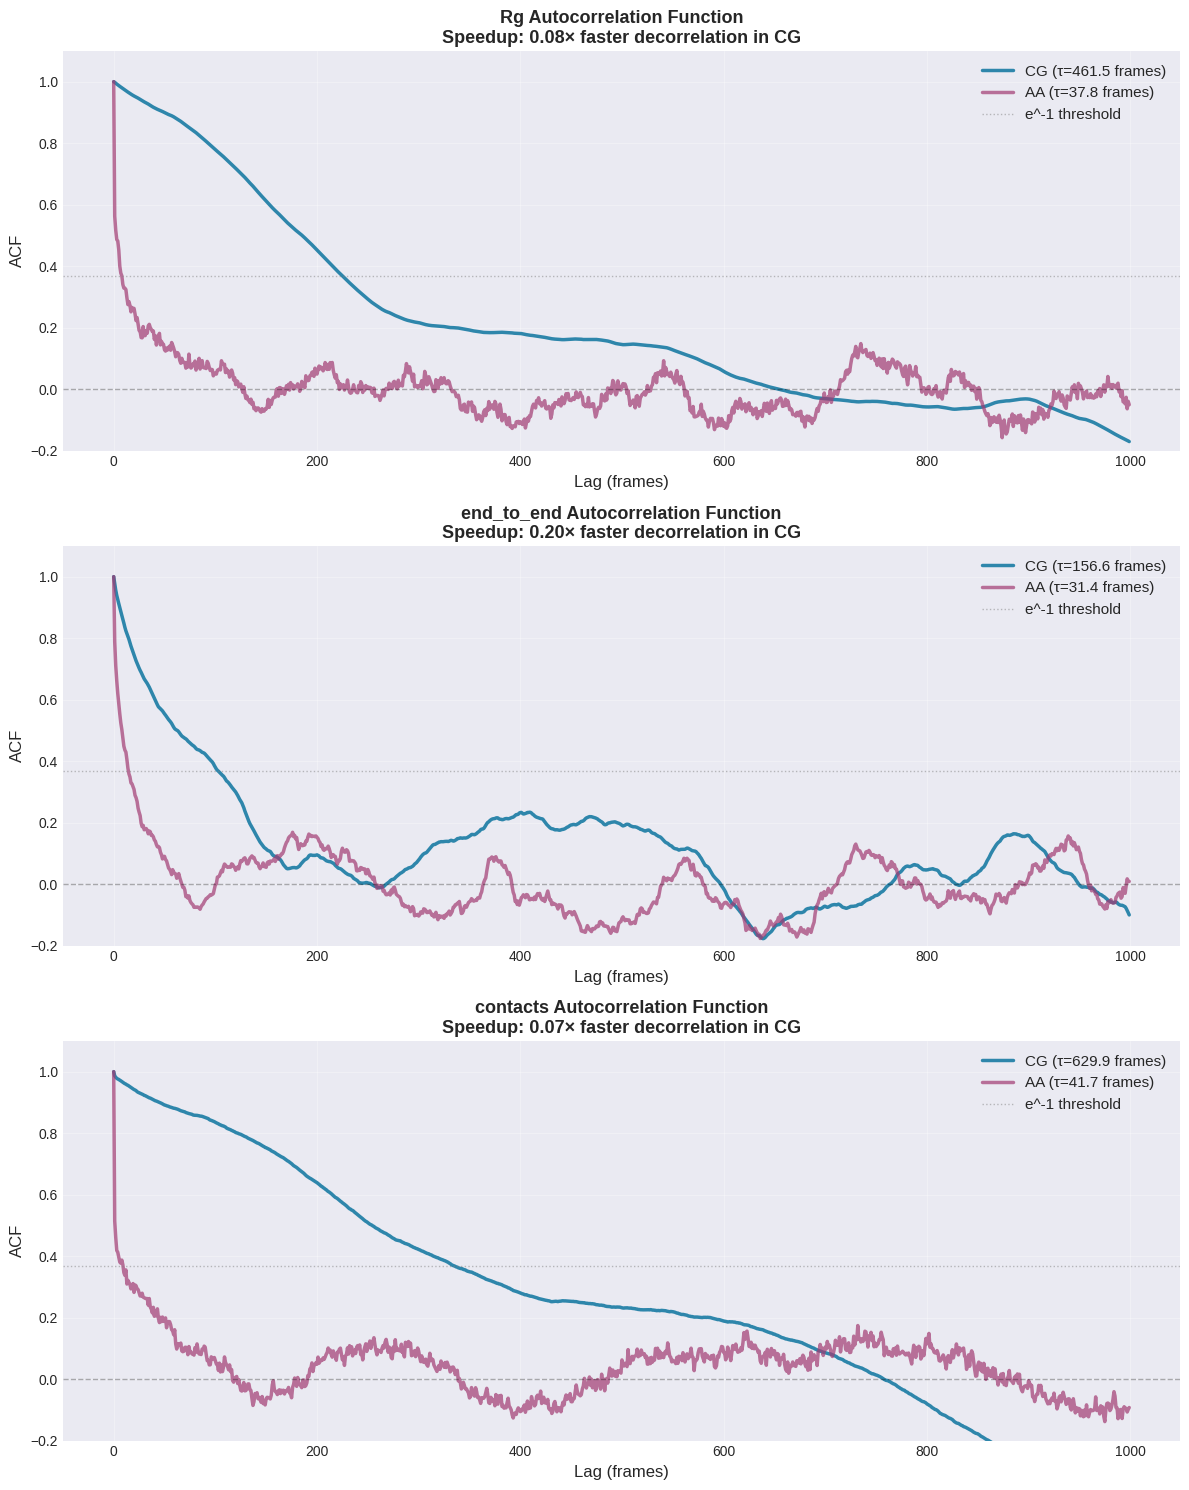

✓ Autocorrelation plots saved


In [13]:
fig, axes = plt.subplots(n_cvs, 1, figsize=(12, 5*n_cvs))
if n_cvs == 1:
    axes = [axes]

for idx, (cv_name, _) in enumerate(cv_list):
    dyn = report['dynamics'][cv_name]
    ax = axes[idx]
    
    # Plot ACF
    lag = np.arange(len(dyn['acf_cg']))
    ax.plot(lag, dyn['acf_cg'], 
            label=f"CG (τ={dyn['tau_cg']:.1f} frames)", 
            linewidth=2.5, color='#2E86AB')
    
    if 'acf_aa' in dyn:
        lag_aa = np.arange(len(dyn['acf_aa']))
        ax.plot(lag_aa, dyn['acf_aa'], 
                label=f"AA (τ={dyn['tau_aa']:.1f} frames)", 
                linewidth=2.5, color='#A23B72', alpha=0.7)
        
        title = f"{cv_name} Autocorrelation Function\n"
        title += f"Speedup: {dyn['speedup']:.2f}× faster decorrelation in CG"
        ax.set_title(title, fontsize=13, fontweight='bold')
    else:
        ax.set_title(f"{cv_name} Autocorrelation", fontsize=13, fontweight='bold')
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.3, linewidth=1)
    ax.axhline(np.exp(-1), color='gray', linestyle=':', alpha=0.5, linewidth=1, 
               label='e^-1 threshold')
    ax.set_xlabel('Lag (frames)', fontsize=12)
    ax.set_ylabel('ACF', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.2, 1.1])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'autocorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Autocorrelation plots saved")

### 10.4 Sampling Efficiency Summary

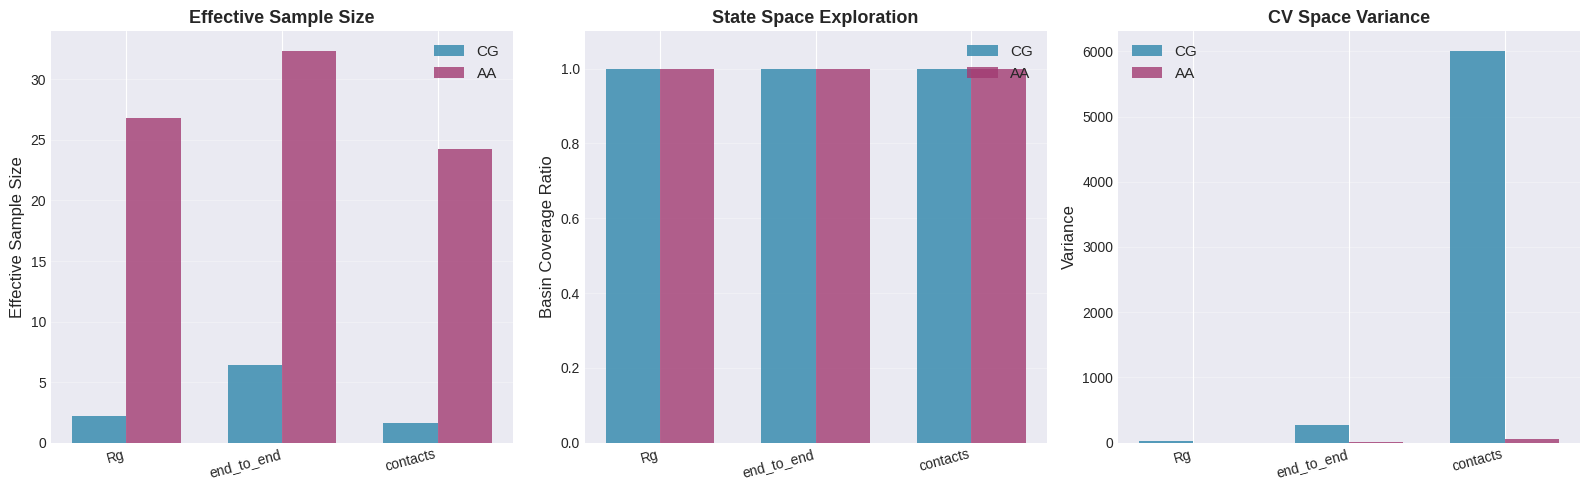

✓ Sampling efficiency plots saved


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cv_names = [name for name, _ in cv_list]
colors_cg = '#2E86AB'
colors_aa = '#A23B72'

# ESS comparison
ax = axes[0]
ess_cg = [report['sampling'][name]['ess']['ess_cg'] for name in cv_names]

if 'ess_aa' in report['sampling'][cv_names[0]]['ess']:
    ess_aa = [report['sampling'][name]['ess']['ess_aa'] for name in cv_names]
    
    x = np.arange(len(cv_names))
    width = 0.35
    ax.bar(x - width/2, ess_cg, width, label='CG', alpha=0.8, color=colors_cg)
    ax.bar(x + width/2, ess_aa, width, label='AA', alpha=0.8, color=colors_aa)
    ax.set_xticks(x)
    ax.legend(fontsize=11)
else:
    ax.bar(cv_names, ess_cg, alpha=0.8, color=colors_cg)

ax.set_xticklabels(cv_names, rotation=15, ha='right')
ax.set_ylabel('Effective Sample Size', fontsize=12)
ax.set_title('Effective Sample Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Basin coverage
ax = axes[1]
coverage_cg = [report['sampling'][name]['basin']['coverage_cg'] for name in cv_names]

if 'coverage_aa' in report['sampling'][cv_names[0]]['basin']:
    coverage_aa = [report['sampling'][name]['basin']['coverage_aa'] for name in cv_names]
    
    x = np.arange(len(cv_names))
    ax.bar(x - width/2, coverage_cg, width, label='CG', alpha=0.8, color=colors_cg)
    ax.bar(x + width/2, coverage_aa, width, label='AA', alpha=0.8, color=colors_aa)
    ax.set_xticks(x)
    ax.legend(fontsize=11)
else:
    ax.bar(cv_names, coverage_cg, alpha=0.8, color=colors_cg)

ax.set_xticklabels(cv_names, rotation=15, ha='right')
ax.set_ylabel('Basin Coverage Ratio', fontsize=12)
ax.set_title('State Space Exploration', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Variance comparison
ax = axes[2]
var_cg = [report['sampling'][name]['variance']['variance_cg'] for name in cv_names]

if 'variance_aa' in report['sampling'][cv_names[0]]['variance']:
    var_aa = [report['sampling'][name]['variance']['variance_aa'] for name in cv_names]
    
    x = np.arange(len(cv_names))
    ax.bar(x - width/2, var_cg, width, label='CG', alpha=0.8, color=colors_cg)
    ax.bar(x + width/2, var_aa, width, label='AA', alpha=0.8, color=colors_aa)
    ax.set_xticks(x)
    ax.legend(fontsize=11)
else:
    ax.bar(cv_names, var_cg, alpha=0.8, color=colors_cg)

ax.set_xticklabels(cv_names, rotation=15, ha='right')
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('CV Space Variance', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sampling_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sampling efficiency plots saved")

## 11. Final Summary

In [15]:
print("\n" + "="*70)
print("EVALUATION COMPLETE")
print("="*70)

print(f"\n📊 Results saved to: {OUTPUT_DIR}")
print("\n📁 Generated files:")
print("  ✓ evaluation_results.pkl      - Complete results (Python pickle)")
print("  ✓ evaluation_summary.txt       - Text summary")
print("  ✓ alignment_rmsd.png           - Alignment quality check")
print("  ✓ rdf_comparison.png           - RDF analysis")
print("  ✓ cv_distributions.png         - CV distribution comparisons")
print("  ✓ autocorrelation.png          - Dynamics analysis")
print("  ✓ sampling_summary.png         - Sampling efficiency metrics")

print("\n" + "="*70)
print("NEXT STEPS")
print("="*70)
print("""
1. Review the evaluation_summary.txt for key metrics
2. Examine the plots to understand CG model performance
3. Use these metrics to benchmark different CG force fields
4. Iterate on CG model parameters to improve performance

This evaluation provides the quality standard for BEAM CG models.
""")


EVALUATION COMPLETE

📊 Results saved to: ../results/stage1_evaluation

📁 Generated files:
  ✓ evaluation_results.pkl      - Complete results (Python pickle)
  ✓ evaluation_summary.txt       - Text summary
  ✓ alignment_rmsd.png           - Alignment quality check
  ✓ rdf_comparison.png           - RDF analysis
  ✓ cv_distributions.png         - CV distribution comparisons
  ✓ autocorrelation.png          - Dynamics analysis
  ✓ sampling_summary.png         - Sampling efficiency metrics

NEXT STEPS

1. Review the evaluation_summary.txt for key metrics
2. Examine the plots to understand CG model performance
3. Use these metrics to benchmark different CG force fields
4. Iterate on CG model parameters to improve performance

This evaluation provides the quality standard for BEAM CG models.



## 12. Key Metrics Summary Table

In [16]:
!pip install pandas
import pandas as pd

# Create summary table
summary_data = []

for cv_name in cv_names:
    row = {'CV': cv_name}
    
    # Distribution
    dist = report['distribution'][cv_name]
    if 'ks_statistic' in dist:
        row['KS_stat'] = f"{dist['ks_statistic']:.3f}"
        row['JS_div'] = f"{dist['js_divergence']:.3f}"
        row['Overlap'] = f"{dist['overlap_coefficient']:.3f}"
    
    # Dynamics
    dyn = report['dynamics'][cv_name]
    row['tau_CG'] = f"{dyn['tau_cg']:.1f}"
    if 'tau_aa' in dyn:
        row['tau_AA'] = f"{dyn['tau_aa']:.1f}"
        row['Speedup'] = f"{dyn['speedup']:.2f}×"
    
    # Sampling
    samp = report['sampling'][cv_name]
    row['ESS_CG'] = f"{samp['ess']['ess_cg']:.0f}"
    row['Basin_Cov'] = f"{samp['basin']['coverage_cg']:.2f}"
    row['Variance'] = f"{samp['variance']['variance_cg']:.4f}"
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("KEY METRICS SUMMARY")
print("="*70)
print(summary_df.to_string(index=False))

# Save to CSV
summary_df.to_csv(OUTPUT_DIR / 'metrics_summary.csv', index=False)
print(f"\n✓ Metrics table saved to: {OUTPUT_DIR / 'metrics_summary.csv'}")

print("\n" + "="*70)
print("✅ STAGE 1 CG EVALUATION COMPLETE!")
print("="*70)


KEY METRICS SUMMARY
        CV KS_stat JS_div Overlap tau_CG tau_AA Speedup ESS_CG Basin_Cov  Variance
        Rg   0.822  0.691   0.376  461.5   37.8   0.08×      2      1.00   23.3457
end_to_end   0.550  0.468   0.583  156.6   31.4   0.20×      6      1.00  269.5982
  contacts   0.863  0.733   0.342  629.9   41.7   0.07×      2      1.00 6006.8922

✓ Metrics table saved to: ../results/stage1_evaluation/metrics_summary.csv

✅ STAGE 1 CG EVALUATION COMPLETE!
